In [1]:
from science_jubilee.JubileeManager import JubileeManager
#from science_jubilee.tools.Camera import Camera
from science_jubilee.tools.Tool import Tool

In [2]:
# Connexion à la Jubilee
jm = JubileeManager(address="10.0.9.55", simulated=True)

2026-02-27 15:06:03 - [JubileeController]  - INFO - Initializing JubileeController (simulated=True, address=10.0.9.55)
2026-02-27 15:06:03 - [JubileeController]  - WARNING - Disconnecting this application from the network will halt connection to Jubilee.
2026-02-27 15:06:03 - [JubileeController]  - INFO - Running in simulation mode. No connection established.
2026-02-27 15:06:03 - [JubileeManager]     - INFO - JubileeManager initialized (simulated=True, max_tools=4).


In [3]:
# Homing
jm.controller.home_all()

Is a tool currently mounted? [y/n]  n
Is the deck clear of any obstacles? [y/n]  y


# Preparation de l'expérience : 
- 1 Placer le deck d'expérience et l'enregistrer
- 2 Placer les outils nécéssaires et les enregistrer

In [4]:
# Descendre le plateau pour positionner le deck
jm.controller.move_to(z=300)
jm.controller.move_to(x=150, y=150)

2026-02-27 15:06:37 - [JubileeController]  - INFO - (SIMULATED) move_to(x=None, y=None, z=300, u=None, s=6000, param=None, wait=False)
2026-02-27 15:06:37 - [JubileeController]  - INFO - (SIMULATED) move_to(x=150, y=150, z=None, u=None, s=6000, param=None, wait=False)


In [5]:
# Enregistrer le deck
deck = jm.load_deck("experience1")

2026-02-27 15:06:41 - [Deck]               - INFO - Loading deck configuration from: D:\Polytech\2025-2026\projet_indus\science-jubilee\src\science_jubilee\decks\deck_definition\experience1.json
2026-02-27 15:06:42 - [Deck]               - INFO - Deck 'Experience1' loaded with 7 slots.
2026-02-27 15:06:42 - [JubileeManager]     - INFO - Deck 'Experience1' loaded from 'D:\Polytech\2025-2026\projet_indus\science-jubilee\src\science_jubilee\decks\deck_definition'.


In [6]:
jm.deck.unload_all_labware()

2026-02-27 15:06:49 - [Deck]               - WARNING - No labware to unload in any slot.


DeckEmptyError: No labware to unload in any slot.

In [7]:
# Enregistrer les labwares sur le deck
labware0 = jm.deck.load_labware(slot=0, labware_filename="greiner_24_wellplate_3300ul_orth.json", order="rows") # Ca change rien rows ou columns ??
labware1 = jm.deck.load_labware(slot=1, labware_filename="greiner_24_wellplate_3300ul_orth.json", order="rows")
labware2 = jm.deck.load_labware(slot=2, labware_filename="greiner_24_wellplate_3300ul_orth.json", order="rows")
labware3 = jm.deck.load_labware(slot=3, labware_filename="greiner_24_wellplate_3300ul_orth.json", order="rows")

#labware4 = jm.deck.load_labware(slot=4, labware_filename="greiner_24_wellplate_3300ul_orth.json", order="rows")
#labware5 = jm.deck.load_labware(slot=5, labware_filename="greiner_24_wellplate_3300ul_orth.json", order="rows")
#labware6 = jm.deck.load_labware(slot=6, labware_filename="greiner_24_wellplate_3300ul_orth.json", order="rows")

2026-02-27 15:07:04 - [Deck]               - INFO - Labware 'greiner_24_wellplate_3300ul_orth.json' loaded into slot 0.
2026-02-27 15:07:04 - [Deck]               - INFO - Labware 'greiner_24_wellplate_3300ul_orth.json' loaded into slot 1.
2026-02-27 15:07:04 - [Deck]               - INFO - Labware 'greiner_24_wellplate_3300ul_orth.json' loaded into slot 2.
2026-02-27 15:07:04 - [Deck]               - INFO - Labware 'greiner_24_wellplate_3300ul_orth.json' loaded into slot 3.


In [8]:
for well_name, well in labware0.wells.items():
    print(f"Well {well_name}: x={well.x}, y={well.y}, z={well.z}")

Well A1: x=15.0, y=15.0, z=2.5
Well B1: x=34.5, y=15.0, z=2.5
Well C1: x=54.0, y=15.0, z=2.5
Well D1: x=73.5, y=15.0, z=2.5
Well A2: x=15.0, y=34.5, z=2.5
Well B2: x=34.5, y=34.5, z=2.5
Well C2: x=54.0, y=34.5, z=2.5
Well D2: x=73.5, y=34.5, z=2.5
Well A3: x=15.0, y=54.0, z=2.5
Well B3: x=34.5, y=54.0, z=2.5
Well C3: x=54.0, y=54.0, z=2.5
Well D3: x=73.5, y=54.0, z=2.5
Well A4: x=15.0, y=73.5, z=2.5
Well B4: x=34.5, y=73.5, z=2.5
Well C4: x=54.0, y=73.5, z=2.5
Well D4: x=73.5, y=73.5, z=2.5
Well A5: x=15.0, y=93.0, z=2.5
Well B5: x=34.5, y=93.0, z=2.5
Well C5: x=54.0, y=93.0, z=2.5
Well D5: x=73.5, y=93.0, z=2.5
Well A6: x=15.0, y=112.5, z=2.5
Well B6: x=34.5, y=112.5, z=2.5
Well C6: x=54.0, y=112.5, z=2.5
Well D6: x=73.5, y=112.5, z=2.5


In [9]:
# Enregistrer les outils
tool0 = Tool(0, "Camera")
jm.load_tool(tool0, 0)
jm.set_tool_offset(0, (0, -43.5,0))

2025-06-04 12:59:18 - [Tool]               - INFO - Tool 'Camera' (index 0) initialized.
2025-06-04 12:59:18 - [JubileeManager]     - INFO - Tool 'Camera' loaded at index 0.
2025-06-04 12:59:18 - [JubileeManager]     - INFO - Offset for tool at index 0 set to (0, -43.5, 0).


In [9]:
jm.status()

{'deck': 'Experience1',
 'tools': [{'index': 0, 'name': 'Camera'}],
 'active_tool_index': None,
 'active_tool_name': None,
 'tool_offsets': {0: (0, -43.5, 0)}}

In [10]:
jm.set_active_tool_by_name("Camera")

2025-06-04 11:06:54 - [JubileeManager]     - INFO - Tool 'Camera' at index 0 set as active tool.


In [11]:
jm.deck.get_slot_coordinates(0)

(8.5, 12.5)

In [12]:
jm.deck.get_all_slot_machine_coordinates()

{'0': (8.5, 12.5),
 '1': (8.5, 150.0),
 '2': (201.5, 12.5),
 '3': (201.5, 150.0),
 '4': (150.0, 45.0),
 '5': (150.0, 145.0),
 '6': (150.0, 245.0)}

In [13]:
a = jm.deck.get_well_machine_coordinates(2,"A1")
print(a)

(216.5, 27.5, 2.5)


In [14]:
labware2.get_well_coordinates("A1")

(15.0, 15.0, 2.5)

# Debut de l'expérience : 

In [11]:
for repeat in range(1):
    
    # Raise LED panels + turn off LEDs


    jm.controller.pickup_tool_sequence(0)
    jm.controller.move_to(z=100)

    for slot_index in jm.deck.list_slots():
        slot = jm.deck.get_slot(slot_index)
        if slot.has_labware and slot.labware is not None:
            labware = slot.labware
            for well_name in labware.wells:
                x, y, z = jm.deck.get_well_machine_coordinates(slot_index, well_name)
                print(f"Slot {slot_index} - Well {well_name}: x={x}, y={y}, z={z}")
                jm.move_active_tool_effector_to(x, y, z=60, s=5000, wait=True)
                # take_picture()

    jm.controller.move_to(z=100)
    jm.controller.park_tool_sequence(0)
    
    # Lower LED panels + turn on light

2025-06-04 12:59:24 - [JubileeController]  - INFO - Starting pickup_tool sequence for tool 0.
2025-06-04 12:59:24 - [JubileeController]  - INFO - (SIMULATED) pickup_tool_sequence(index=0, z_park=None)
2025-06-04 12:59:24 - [JubileeController]  - INFO - (SIMULATED) move_to(x=None, y=None, z=100, u=None, s=6000, param=None, wait=False)
2025-06-04 12:59:24 - [JubileeController]  - INFO - (SIMULATED) move_to(x=None, y=None, z=100, u=None, s=6000, param=None, wait=False)
2025-06-04 12:59:24 - [JubileeController]  - INFO - Starting park_tool sequence for tool 0.
2025-06-04 12:59:24 - [JubileeController]  - INFO - (SIMULATED) park_tool_sequence(index=0, z_park=None)


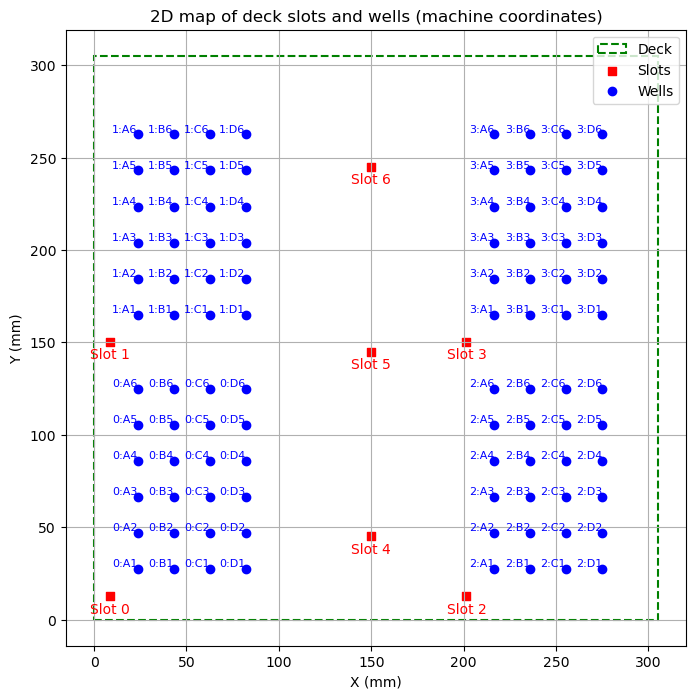

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Remplir ces listes avec tes données
slot_xs, slot_ys, slot_labels = [], [], []
well_xs, well_ys, well_labels = [], [], []

# Exemple d'utilisation avec un objet jm (JubileeManager)
for slot_index in jm.deck.list_slots():
    # Machine coordinates of the slot center
    slot_x, slot_y = jm.deck.get_slot_machine_coordinates(slot_index)
    slot_xs.append(slot_x)
    slot_ys.append(slot_y)
    slot_labels.append(f"Slot {slot_index}")

    slot = jm.deck.get_slot(slot_index)
    if slot.has_labware and slot.labware is not None:
        for well_name in slot.labware.wells:
            coords = jm.deck.get_well_machine_coordinates(slot_index, well_name)
            if coords is not None:
                well_xs.append(coords[0])
                well_ys.append(coords[1])
                well_labels.append(f"{slot_index}:{well_name}")

plt.figure(figsize=(8, 8))
ax = plt.gca()

# Add the deck (green rectangle)
deck_rect = patches.Rectangle((0, 0), 305, 305, linewidth=1.5, edgecolor='green', facecolor='none', linestyle='--', label='Deck')
ax.add_patch(deck_rect)

plt.scatter(slot_xs, slot_ys, c='r', marker='s', label='Slots')
for x, y, label in zip(slot_xs, slot_ys, slot_labels):
    plt.text(x, y - 3, label, fontsize=10, ha='center', va='top', color='red')
plt.scatter(well_xs, well_ys, c='b', marker='o', label='Wells')
for x, y, label in zip(well_xs, well_ys, well_labels):
    plt.text(x, y, label, fontsize=8, ha='right', va='bottom', color='blue')

plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('2D map of deck slots and wells (machine coordinates)')
plt.xlim(0, 305)
plt.ylim(0, 305)
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()